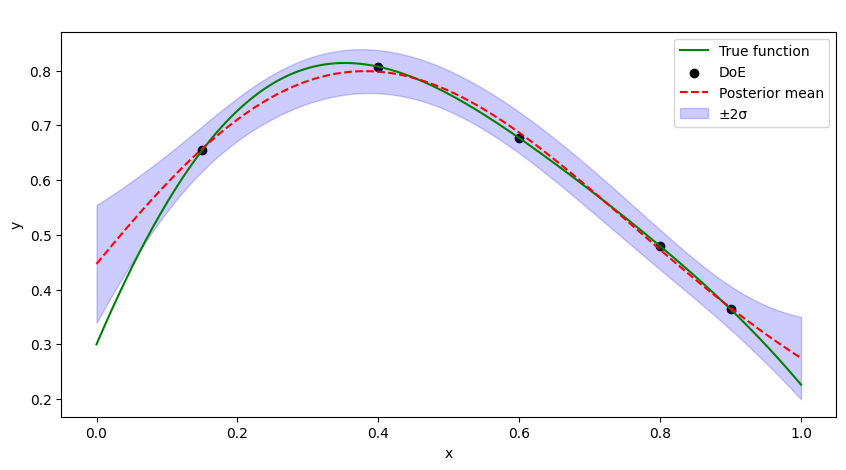

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# True function
def f(x):
    return np.sin(3*x) + 0.3*np.cos(5*x)

# Training data
X = np.array([[0.15], [0.4], [0.6], [0.8], [0.9]])
y = f(X).ravel()

# Kernel (RBF + small noise)
kernel = 1.0 * RBF(length_scale=0.2) + WhiteKernel(noise_level=1e-6)

gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
gp.fit(X, y)

# Prediction grid
X_star = np.linspace(0, 1, 300).reshape(-1, 1)
mu, sigma = gp.predict(X_star, return_std=True)

# Plot
plt.figure(figsize=(10,5))
plt.plot(X_star, f(X_star), "g", label="True function")
plt.scatter(X, y, c="k", label="DoE")
plt.plot(X_star, mu, "r--", label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 mu - 2*sigma,
                 mu + 2*sigma,
                 color="blue", alpha=0.2, label="±2σ")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title(" ")
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from smt.surrogate_models import KRG

# True function
def f(x):
    return np.sin(3*x) + 0.3*np.cos(5*x)

# Training data
X = np.array([[0.1], [0.4], [0.8]])
y = f(X)

# Kriging model
krg = KRG(theta0=[0.2], poly='constant', print_global=False)
krg.set_training_values(X, y)
krg.train()

# Prediction
X_star = np.linspace(0, 1, 300).reshape(-1, 1)
mu = krg.predict_values(X_star).ravel()
sigma = np.sqrt(krg.predict_variances(X_star)).ravel()

# Plot
plt.figure(figsize=(10,5))
plt.plot(X_star, f(X_star), "g", label="True function")
plt.scatter(X, y, c="k", label="DoE")
plt.plot(X_star, mu, "r--", label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 mu - 2*sigma,
                 mu + 2*sigma,
                 color="red", alpha=0.2, label="±2σ")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Kriging (SMT)")
plt.show()


ModuleNotFoundError: No module named 'smt'